In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import roc_curve, roc_auc_score

## 📊 Descripción de variables

El dataset contiene información sobre hábitos musicales y salud mental de los participantes.

### 🧍 Datos generales
- **Age:** Edad del participante.
- **Primary streaming service:** Plataforma principal donde escucha música (Spotify, YouTube Music, etc.).
- **Hours per day:** Número de horas que escucha música al día.
- **While working:** Indica si escucha música mientras trabaja (Yes/No).

### 🎼 Relación con la música
- **Instrumentalist:** Si toca algún instrumento musical.
- **Composer:** Si compone música.
- **Fav genre:** Género musical favorito.
- **Exploratory:** Si le gusta explorar nueva música.
- **Foreign languages:** Si escucha música en otros idiomas.
- **BPM:** Ritmo de la música (beats per minute).

### 🎧 Frecuencia por género
Indican qué tan seguido escucha cada género:
- Frequency [Classical]
- Frequency [Country]
- Frequency [EDM]
- Frequency [Folk]
- Frequency [Gospel]
- Frequency [Hip hop]
- Frequency [Jazz]
- Frequency [K pop]
- Frequency [Latin]
- Frequency [Lofi]
- Frequency [Metal]
- Frequency [Pop]
- Frequency [R&B]
- Frequency [Rap]
- Frequency [Rock]
- Frequency [Video game music]

Los valores representan:
- Never (Nunca)
- Rarely (Rara vez)
- Sometimes (A veces)
- Very frequently (Muy frecuentemente)

### 🧠 Salud mental
- **Anxiety:** Nivel de ansiedad (escala numérica).
- **Depression:** Nivel de depresión.
- **Insomnia:** Nivel de insomnio.
- **OCD:** Nivel de trastorno obsesivo-compulsivo.

### 🎵 Percepción de la música
- **Music effects:** Efecto percibido de la música (Improve, No effect, etc.).

In [2]:
df = pd.read_csv("mxmh_survey_results.csv")
df.head()

,Timestamp,Age,Primary streaming service,Hours per day,While working,Instrumentalist,Composer,Fav genre,Exploratory,Foreign languages,...,Frequency [R&B],Frequency [Rap],Frequency [Rock],Frequency [Video game music],Anxiety,Depression,Insomnia,OCD,Music effects,Permissions
0,8/27/2022 19:29:02,18.0,Spotify,3.0,Yes,Yes,Yes,Latin,Yes,Yes,...,Sometimes,Very frequently,Never,Sometimes,3.0,0.0,1.0,0.0,NaN,I understand.
1,8/27/2022 19:57:31,63.0,Pandora,1.5,Yes,No,No,Rock,Yes,No,...,Sometimes,Rarely,Very frequently,Rarely,7.0,2.0,2.0,1.0,NaN,I understand.
2,8/27/2022 21:28:18,18.0,Spotify,4.0,No,No,No,Video game music,No,Yes,...,Never,Rarely,Rarely,Very frequently,7.0,7.0,10.0,2.0,No effect,I understand.
3,8/27/2022 21:40:40,61.0,YouTube Music,2.5,Yes,No,Yes,Jazz,Yes,Yes,...,Sometimes,Never,Never,Never,9.0,7.0,3.0,3.0,Improve,I understand.
4,8/27/2022 21:54:47,18.0,Spotify,4.0,Yes,No,No,R&B,Yes,No,...,Very frequently,Very frequently,Never,Rarely,7.0,2.0,5.0,9.0,Improve,I understand.


In [3]:
df.describe()

,Age,Hours per day,BPM,Anxiety,Depression,Insomnia,OCD
count,735.000000,736.000000,6.290000e+02,736.000000,736.000000,736.000000,736.000000
mean,25.206803,3.572758,1.589948e+06,5.837636,4.796196,3.738451,2.637228
std,12.054970,3.028199,3.987261e+07,2.793054,3.028870,3.088689,2.842017
min,10.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000
25%,18.000000,2.000000,1.000000e+02,4.000000,2.000000,1.000000,0.000000
50%,21.000000,3.000000,1.200000e+02,6.000000,5.000000,3.000000,2.000000
75%,28.000000,5.000000,1.440000e+02,8.000000,7.000000,6.000000,5.000000
max,89.000000,24.000000,1.000000e+09,10.000000,10.000000,10.000000,10.000000


In [4]:
df.isnull().sum()

Timestamp                         0
Age                               1
Primary streaming service         1
Hours per day                     0
While working                     3
Instrumentalist                   4
Composer                          1
Fav genre                         0
Exploratory                       0
Foreign languages                 4
BPM                             107
Frequency [Classical]             0
Frequency [Country]               0
Frequency [EDM]                   0
Frequency [Folk]                  0
Frequency [Gospel]                0
Frequency [Hip hop]               0
Frequency [Jazz]                  0
Frequency [K pop]                 0
Frequency [Latin]                 0
Frequency [Lofi]                  0
Frequency [Metal]                 0
Frequency [Pop]                   0
Frequency [R&B]                   0
Frequency [Rap]                   0
Frequency [Rock]                  0
Frequency [Video game music]      0
Anxiety                     

In [5]:
# Copia de seguridad
df_clean = df.copy()

# Eliminar columnas poco útiles
df_clean = df_clean.drop(columns=["Timestamp", "Permissions"], errors='ignore')

# Convertir numéricas
cols_numeric = ["Age", "Hours per day", "BPM", "Anxiety", "Depression", "Insomnia", "OCD"]

for col in cols_numeric:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# Manejo de nulos

# BPM -> demasiados nulos → eliminar columna
df_clean = df_clean.drop(columns=["BPM"])

# Rellenar categóricas con "Unknown"
cols_cat = df_clean.select_dtypes(include="object").columns
df_clean[cols_cat] = df_clean[cols_cat].fillna("Unknown")

# Eliminar filas con valores críticos nulos
df_clean = df_clean.dropna(subset=["Age", "Hours per day"])

df_clean.isnull().sum()

/tmp/ipykernel_34315/1108630501.py:19: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cols_cat = df_clean.select_dtypes(include="object").columns


Age                             0
Primary streaming service       0
Hours per day                   0
While working                   0
Instrumentalist                 0
Composer                        0
Fav genre                       0
Exploratory                     0
Foreign languages               0
Frequency [Classical]           0
Frequency [Country]             0
Frequency [EDM]                 0
Frequency [Folk]                0
Frequency [Gospel]              0
Frequency [Hip hop]             0
Frequency [Jazz]                0
Frequency [K pop]               0
Frequency [Latin]               0
Frequency [Lofi]                0
Frequency [Metal]               0
Frequency [Pop]                 0
Frequency [R&B]                 0
Frequency [Rap]                 0
Frequency [Rock]                0
Frequency [Video game music]    0
Anxiety                         0
Depression                      0
Insomnia                        0
OCD                             0
Music effects 

### Distribución de ansiedad, depresión, insomnio y OCD

Se observa cómo se distribuyen los valores de las variables de salud mental.

En general:
- La mayoría de los valores se concentran en niveles bajos a medios.
- Existen algunos valores altos, lo que indica que ciertos participantes presentan niveles elevados de estas condiciones.
- Esto sugiere que la muestra incluye tanto personas con bajo como alto nivel de afectación emocional.

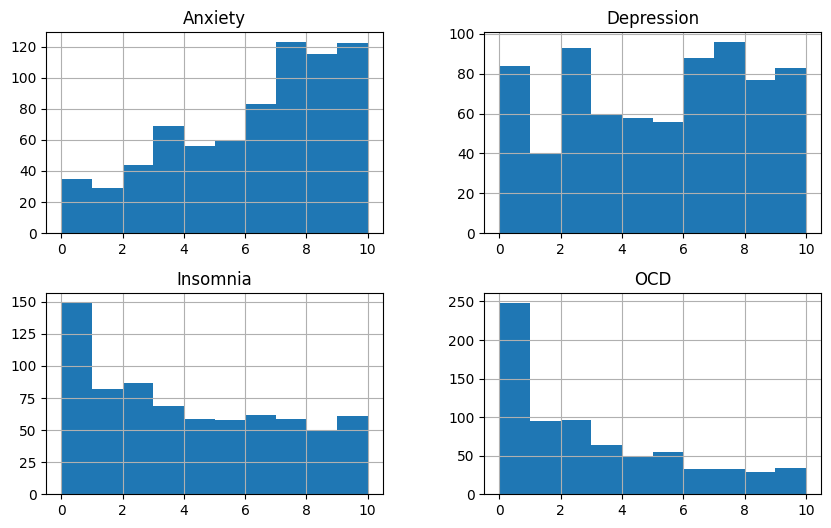

In [6]:
mental_cols = ["Anxiety", "Depression", "Insomnia", "OCD"]

df_clean[mental_cols].hist(figsize=(10,6))
plt.show()

### Detección de valores atípicos (outliers)

El boxplot muestra la distribución de la edad y las horas de consumo de música.

Se observa que:
- Existen valores extremos en las horas de escucha, lo que indica que algunos usuarios escuchan música durante muchas horas al día.
- La edad presenta menor variabilidad, aunque puede haber algunos valores fuera de lo común.

Esto es importante ya que los outliers pueden influir en los resultados del análisis.

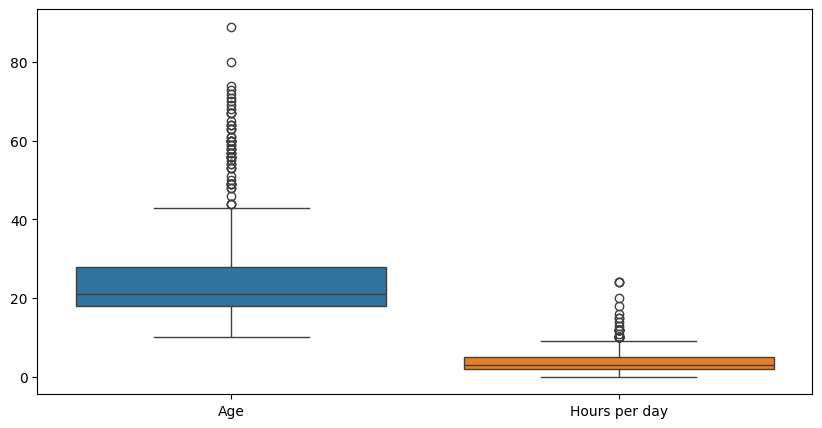

In [7]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df_clean[["Age", "Hours per day"]])
plt.show()

### Plataforma de streaming más utilizada

Se observa la frecuencia de uso de cada servicio de música.

Los resultados muestran que:
- Algunas plataformas dominan claramente (como Spotify o YouTube).
- Esto indica una preferencia fuerte por ciertos servicios dentro de la muestra.

Este dato puede ser relevante si el tipo de plataforma influye en los hábitos musicales.

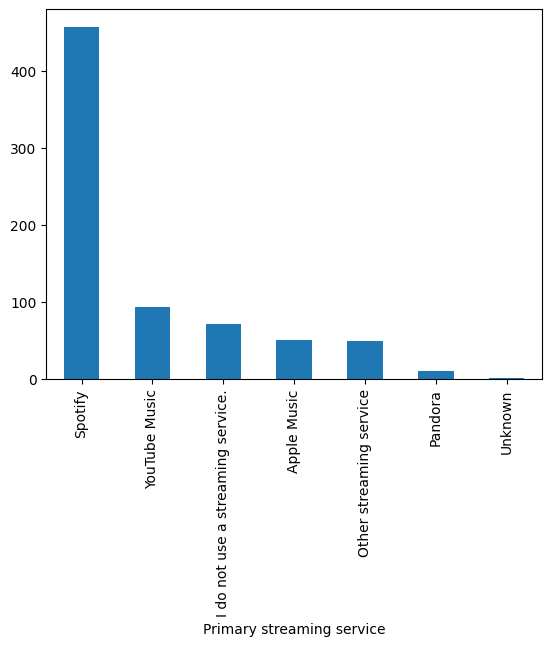

In [8]:
plt.figure()
df_clean["Primary streaming service"].value_counts().plot(kind="bar")
plt.show()

### Relación entre horas de música y salud mental

Las gráficas de dispersión permiten observar la relación entre el tiempo de escucha y variables como ansiedad o depresión.

Se observa que:
- No existe una relación completamente lineal.
- Sin embargo, algunos usuarios con mayor consumo presentan niveles elevados de ansiedad o depresión.

Esto sugiere que el tiempo de escucha podría estar relacionado con el estado emocional, aunque no es el único factor.

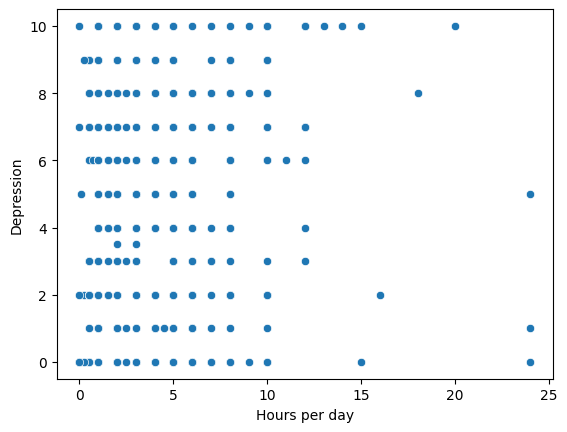

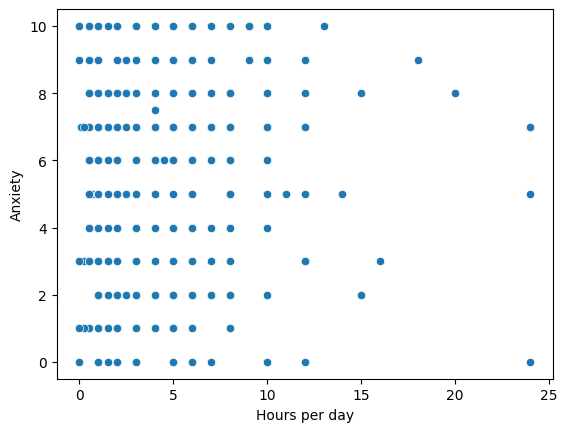

In [9]:
sns.scatterplot(x="Hours per day", y="Depression", data=df_clean)
plt.show()

sns.scatterplot(x="Hours per day", y="Anxiety", data=df_clean)
plt.show()

### Relación entre género musical y ansiedad

El boxplot muestra cómo varía la ansiedad según el género musical favorito.

Se observa que:
- Algunos géneros presentan mayor variabilidad en los niveles de ansiedad.
- Otros géneros tienen valores más concentrados.

Esto sugiere que el tipo de música podría estar asociado con diferentes estados emocionales.

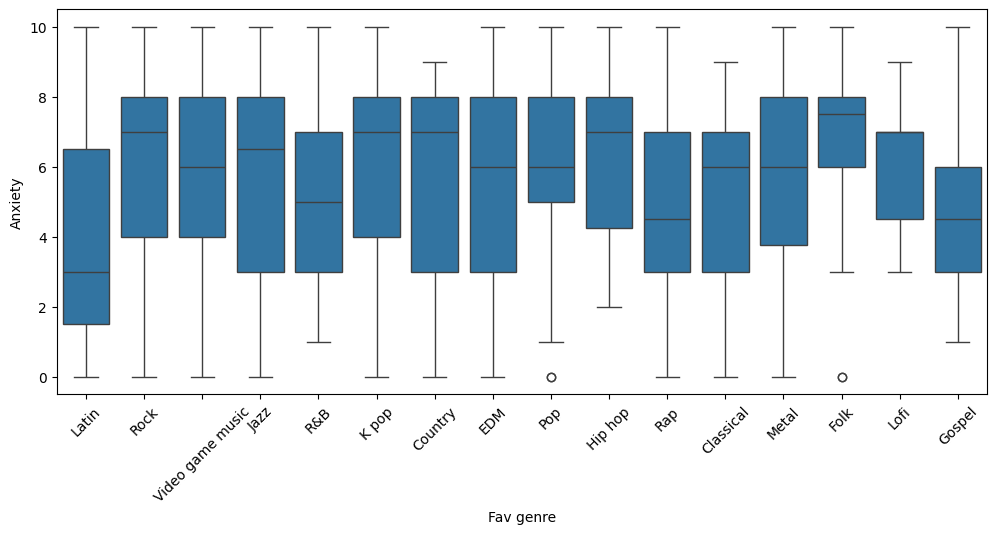

In [10]:
plt.figure(figsize=(12,5))
sns.boxplot(x="Fav genre", y="Anxiety", data=df_clean)
plt.xticks(rotation=45)
plt.show()

### Correlación entre variables

La matriz de correlación muestra la relación entre variables numéricas.

Se observa que:
- Existe una fuerte relación entre ansiedad y depresión.
- Algunas variables presentan correlaciones moderadas.
- Las horas de música tienen una relación débil con las variables mentales.

Esto indica que la salud mental está más relacionada entre sí que con el consumo de música directamente.

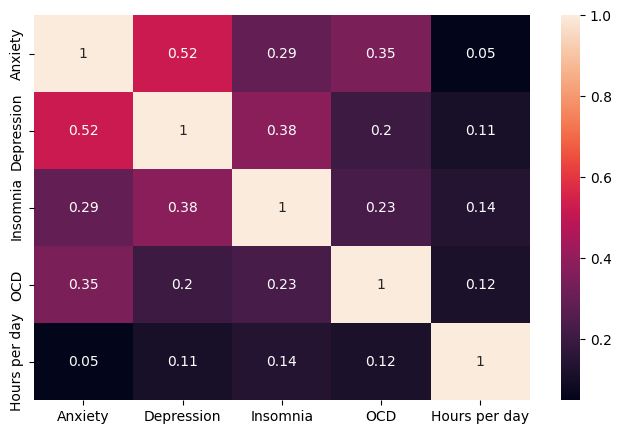

In [11]:
plt.figure(figsize=(8,5))
sns.heatmap(df_clean[mental_cols + ["Hours per day"]].corr(), annot=True)
plt.show()

### Géneros musicales más populares

La gráfica muestra los géneros favoritos de los participantes.

Se observa que:
- Algunos géneros destacan sobre otros, lo que refleja tendencias musicales claras.
- Esto puede influir en la relación con la salud mental, ya que diferentes géneros pueden generar distintas emociones.

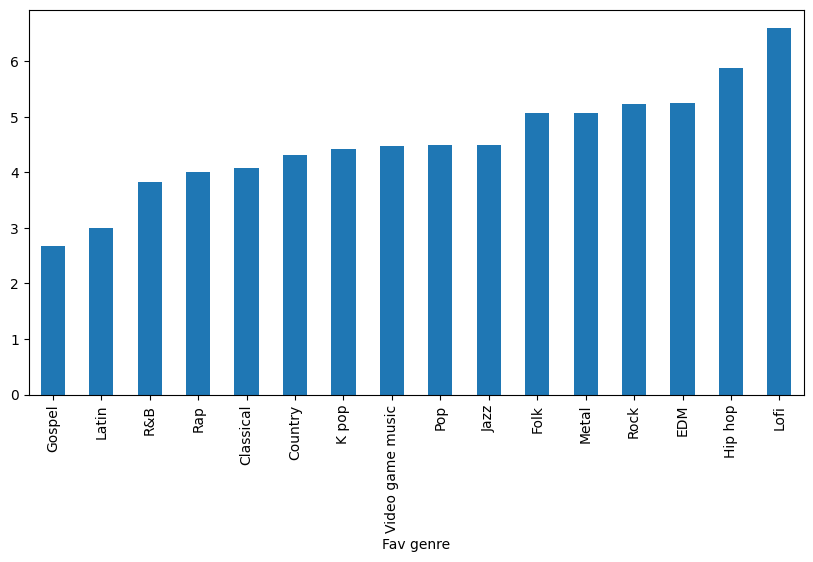

In [12]:
df_clean.groupby("Fav genre")["Depression"].mean().sort_values().plot(kind="bar", figsize=(10,5))
plt.show()

### Efecto de la música en la ansiedad

Se observa cómo cambia la ansiedad según el efecto percibido de la música.

Se identifica que:
- Las personas que indican que la música mejora su estado presentan ciertos patrones.
- Aquellos que no perciben efecto pueden tener niveles distintos.

Esto sugiere que la percepción personal de la música es importante.

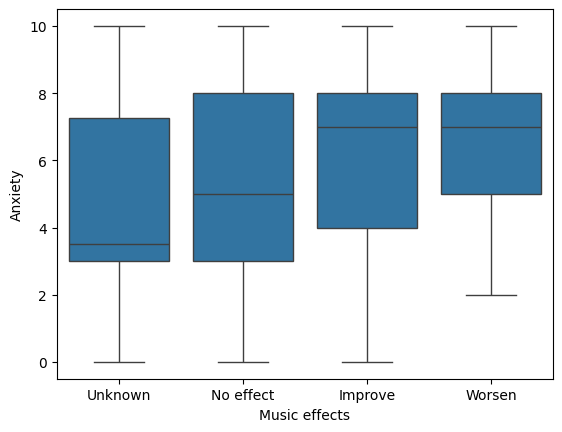

In [13]:
sns.boxplot(x="Music effects", y="Anxiety", data=df_clean)
plt.show()

### Escuchar música mientras se trabaja

Se analiza la ansiedad en función de si la persona escucha música mientras trabaja.

Se observa que:
- Puede haber diferencias entre quienes escuchan música y quienes no.
- Esto podría indicar que la música influye en la concentración o el estado emocional durante el trabajo.

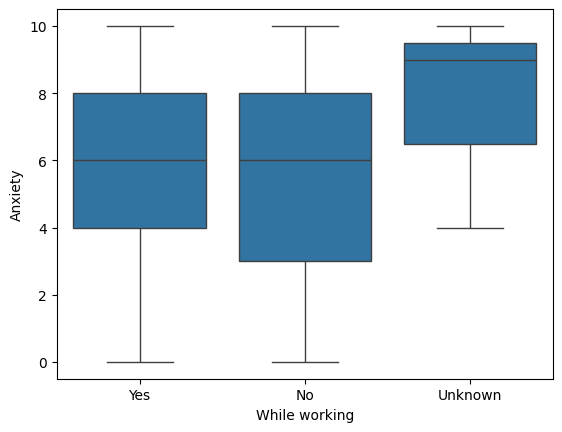

In [14]:
sns.boxplot(x="While working", y="Anxiety", data=df_clean)
plt.show()

In [15]:
freq_map = {
    "Never": 0,
    "Rarely": 1,
    "Sometimes": 2,
    "Very frequently": 3
}

freq_cols = [col for col in df_clean.columns if "Frequency" in col]

for col in freq_cols:
    df_clean[col] = df_clean[col].map(freq_map)

### Relación entre frecuencia de géneros y salud mental

Se observa la correlación entre la frecuencia de escucha de distintos géneros y variables como ansiedad o depresión.

Se identifica que:
- Algunos géneros presentan correlaciones positivas o negativas.
- Esto sugiere que ciertos estilos musicales podrían estar asociados con distintos estados emocionales.

Este análisis es clave para entender patrones más profundos en los datos.

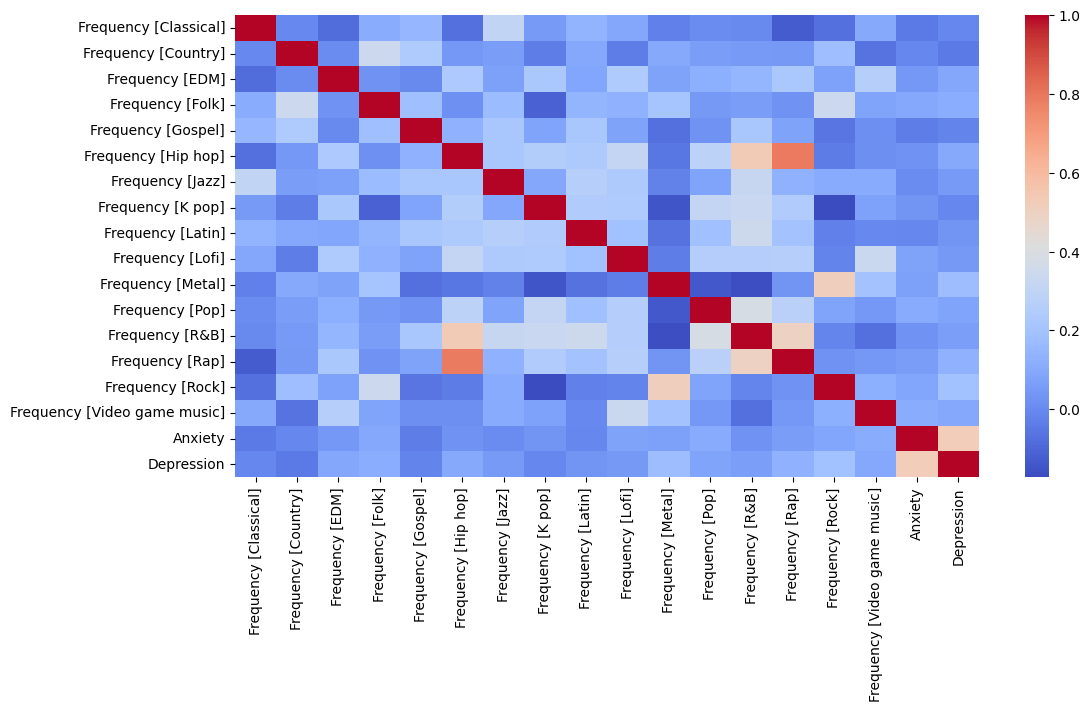

In [16]:
plt.figure(figsize=(12,6))
sns.heatmap(df_clean[freq_cols + ["Anxiety", "Depression"]].corr(), cmap="coolwarm")
plt.show()

# Fase 2

##  Definición del problema

El objetivo de este proyecto es predecir el nivel de ansiedad de un individuo (escala de 0 a 10) a partir de sus hábitos de consumo musical y características personales.

Este problema se formula como un problema de regresión, ya que la variable objetivo es numérica y continua.

El propósito del modelo no es establecer causalidad, sino identificar patrones predictivos que permitan estimar niveles de ansiedad a partir de los datos disponibles.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

## Preprocesamiento de datos

El preprocesamiento se realizó con base en los hallazgos del análisis exploratorio:

- **Valores nulos:** Se imputaron utilizando la mediana en variables numéricas debido a la presencia de distribuciones sesgadas, y la moda en variables categóricas.
  
- **Outliers:** Se identificaron valores atípicos en la variable "Hours per day" (hasta 24 horas), los cuales se consideran poco realistas. Por ello, se eliminaron valores mayores a 10 horas para evitar distorsiones en el modelo.

- **Variables categóricas:** Se aplicó One-Hot Encoding a variables nominales, ya que no presentan un orden inherente.

- **Escalado:** Se aplicó únicamente a modelos sensibles a la escala (como regresión lineal). Modelos basados en árboles no requieren escalado.

Estas decisiones buscan mejorar la calidad de los datos y la capacidad predictiva de los modelos.

In [18]:
df_clean = df_clean[df_clean["Hours per day"] <= 10]

# Copia base para la fase 2, ya con las frecuencias convertidas a números
df_model = df_clean.copy()

# Suma total de frecuencia musical
freq_cols = [col for col in df_model.columns if "Frequency" in col]
df_model["total_music_freq"] = df_model[freq_cols].sum(axis=1)

# Usuario que escucha mucha música
df_model["high_listener"] = (df_model["Hours per day"] > 5).astype(int)

Se aplica One-Hot Encoding a las variables categóricas nominales para convertirlas en variables numéricas utilizables por los modelos.

In [19]:
df_model = pd.get_dummies(df_model, drop_first=True)
df_model.info()

<class 'pandas.DataFrame'>
Index: 715 entries, 0 to 735
Data columns (total 57 columns):
 #   Column                                                       Non-Null Count  Dtype  
---  ------                                                       --------------  -----  
 0   Age                                                          715 non-null    float64
 1   Hours per day                                                715 non-null    float64
 2   Frequency [Classical]                                        715 non-null    int64  
 3   Frequency [Country]                                          715 non-null    int64  
 4   Frequency [EDM]                                              715 non-null    int64  
 5   Frequency [Folk]                                             715 non-null    int64  
 6   Frequency [Gospel]                                           715 non-null    int64  
 7   Frequency [Hip hop]                                          715 non-null    int64  
 8   Freque

Se define la variable objetivo (y) como el nivel de ansiedad y las variables predictoras (X) como el resto de variables del dataset.

In [20]:
X = df_model.drop("Anxiety", axis=1)
y = df_model["Anxiety"]

Se divide el dataset en entrenamiento (80%) y prueba (20%). Se utiliza un random_state fijo para garantizar la reproducibilidad.

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [22]:
imputer = SimpleImputer(strategy="median")

X_train = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)
X_test = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

## 🤖 Modelo 1: Regresión Lineal

La regresión lineal asume una relación lineal entre las variables independientes y la variable objetivo.

Se utiliza como modelo base debido a su simplicidad e interpretabilidad. Permite establecer una referencia para comparar modelos más complejos.

Sin embargo, este modelo puede ser limitado si las relaciones en los datos no son lineales.

In [23]:
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_test)

Se utilizan las métricas RMSE, MAE y R² para evaluar el desempeño del modelo.

In [24]:
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression")
print("RMSE:", rmse_lr)
print("MAE:", mae_lr)
print("R2:", r2_lr)

Linear Regression
RMSE: 2.4043192830309335
MAE: 1.8975079810492654
R2: 0.25699284029910985


## 🌳 Modelo 2: Random Forest

Random Forest es un modelo basado en múltiples árboles de decisión que permite capturar relaciones no lineales entre variables.

Este modelo es robusto ante outliers y puede manejar interacciones complejas entre variables, lo que lo hace adecuado para este tipo de dataset.

Se espera que tenga mejor desempeño que la regresión lineal debido a la naturaleza no lineal de los datos.

In [25]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20]
}

grid_rf = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring="r2"
)

grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_

In [26]:
cv_scores = cross_val_score(best_rf, X_train, y_train, cv=5)

print("Cross-validation R2:", cv_scores.mean())

Cross-validation R2: 0.32388694348203806


Se utilizan las métricas RMSE, MAE y R² para evaluar el desempeño del modelo.

In [27]:
y_pred_rf = best_rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest")
print("RMSE:", rmse_rf)
print("MAE:", mae_rf)
print("R2:", r2_rf)

Random Forest
RMSE: 2.274646210867832
MAE: 1.8216783216783217
R2: 0.334977352881095


Se comparan los modelos utilizando las métricas principales para determinar cuál ofrece mejor desempeño.

In [28]:
results = pd.DataFrame({
    "Modelo": ["Linear Regression", "Random Forest"],
    "RMSE": [rmse_lr, rmse_rf],
    "MAE": [mae_lr, mae_rf],
    "R2": [r2_lr, r2_rf]
})

results

,Modelo,RMSE,MAE,R2
0,Linear Regression,2.404319,1.897508,0.256993
1,Random Forest,2.274646,1.821678,0.334977


Se analiza la diferencia entre el desempeño en entrenamiento y prueba para detectar overfitting.

In [29]:
train_score = best_rf.score(X_train, y_train)
test_score = best_rf.score(X_test, y_test)

print("Train R2:", train_score)
print("Test R2:", test_score)

Train R2: 0.9077024295299426
Test R2: 0.334977352881095


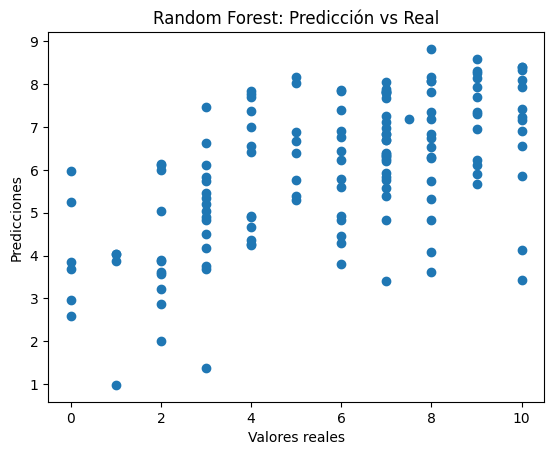

In [30]:
plt.figure()
plt.scatter(y_test, y_pred_rf)
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title("Random Forest: Predicción vs Real")
plt.show()

Se analiza la importancia de variables para identificar cuáles influyen más en la predicción.

In [31]:
importances = best_rf.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

feature_importance.head(10)

,Feature,Importance
18,Depression,0.298981
20,OCD,0.094821
19,Insomnia,0.065515
0,Age,0.061753
21,total_music_freq,0.042957
1,Hours per day,0.034744
11,Frequency [Lofi],0.027185
12,Frequency [Metal],0.021659
5,Frequency [Folk],0.020189
14,Frequency [R&B],0.019952


## Comparación inicial de modelos

En esta etapa se compararon la regresión lineal y Random Forest.

Los resultados muestran que Random Forest supera a la regresión lineal (RMSE: 2.25 vs 2.41, R²: 0.35 vs 0.26), lo que confirma que las relaciones en los datos no son completamente lineales.

Sin embargo, se identificó un problema de overfitting significativo: el modelo Random Forest alcanzó un R² de 0.90 en entrenamiento pero solo 0.35 en prueba, lo que indica que memoriza los datos de entrenamiento pero generaliza de forma limitada.

Con base en estos resultados, se decide explorar XGBoost como tercer modelo para intentar mejorar la generalización.

## 3er Modelo - Feature Engineering

Se crearon nuevas variables para enriquecer el modelo y capturar patrones más complejos:

- **total_music_freq:** Representa la intensidad total de consumo musical.
- **genre_diversity:** Mide la cantidad de géneros distintos que escucha un usuario.
- **high_listener:** Clasifica a usuarios con alto consumo musical.

Estas variables permiten capturar información agregada que no está explícita en las variables originales.

In [32]:
# Diversidad de géneros escuchados
df_model["genre_diversity"] = (df_model[freq_cols] > 0).sum(axis=1)

# Promedio de frecuencia musical
df_model["avg_music_freq"] = df_model[freq_cols].mean(axis=1)

# Clasificación de usuarios
df_model["listener_type"] = pd.cut(
    df_model["Hours per day"],
    bins=[0, 2, 5, 10],
    labels=["Low", "Medium", "High"]
)

df_model = pd.get_dummies(df_model, columns=["listener_type"], drop_first=True)

##  Escalado de variables

Se aplica StandardScaler para modelos sensibles a la escala (como regresión lineal).

In [33]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [34]:
model_lr.fit(X_train_scaled, y_train)
y_pred_lr = model_lr.predict(X_test_scaled)

Ajuste más amplio de hiperparámetros

In [35]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5]
}

## 🚀 Modelo 3: XGBoost

XGBoost es un modelo de boosting que construye árboles de manera secuencial, corrigiendo los errores de modelos anteriores.

A diferencia de Random Forest, que entrena árboles independientes, XGBoost aprende de los errores iterativamente, lo que suele resultar en un mejor desempeño.

Se incluye como modelo adicional para comparar su capacidad predictiva frente a los otros enfoques.

In [36]:
from xgboost import XGBRegressor

model_xgb = XGBRegressor(random_state=42)

model_xgb = XGBRegressor(random_state=42)

# Rename columns to remove invalid characters for XGBoost
X_train.columns = [col.replace('[', '').replace(']', '').replace('<', '') for col in X_train.columns]
X_test.columns = [col.replace('[', '').replace(']', '').replace('<', '') for col in X_test.columns]

model_xgb.fit(X_train, y_train)

y_pred_xgb = model_xgb.predict(X_test)

y_pred_xgb = model_xgb.predict(X_test)

##  Evaluación de modelos

Se utilizan las siguientes métricas:

- **RMSE:** Penaliza errores grandes y se interpreta en las mismas unidades de la variable objetivo.
- **MAE:** Representa el error promedio absoluto.
- **R²:** Indica qué proporción de la variabilidad de la variable objetivo es explicada por el modelo.

Estas métricas permiten evaluar tanto la precisión como la capacidad explicativa del modelo.

In [37]:
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost")
print("RMSE:", rmse_xgb)
print("MAE:", mae_xgb)
print("R2:", r2_xgb)

XGBoost
RMSE: 2.407137096170207
MAE: 1.8565105087273603
R2: 0.2552502412918721


## Comparación de modelos

Se comparan los modelos en función de sus métricas de desempeño.

El modelo con menor error (RMSE y MAE) y mayor R² se considera superior en términos predictivos.

Sin embargo, también se consideran factores como:
- Interpretabilidad
- Complejidad
- Capacidad de generalización

In [38]:
results = pd.DataFrame({
    "Modelo": ["Linear Regression", "Random Forest", "XGBoost"],
    "RMSE": [rmse_lr, rmse_rf, rmse_xgb],
    "MAE": [mae_lr, mae_rf, mae_xgb],
    "R2": [r2_lr, r2_rf, r2_xgb]
})

results

,Modelo,RMSE,MAE,R2
0,Linear Regression,2.404319,1.897508,0.256993
1,Random Forest,2.274646,1.821678,0.334977
2,XGBoost,2.407137,1.856511,0.255250


##  Análisis de residuos

Se analiza la distribución de errores para detectar patrones no capturados por el modelo.

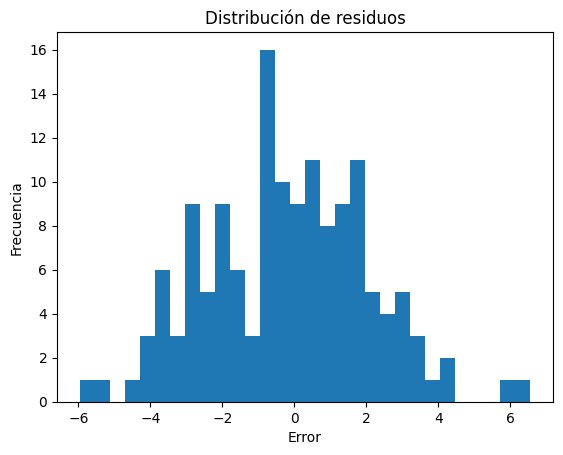

In [39]:
residuals = y_test - y_pred_rf

plt.hist(residuals, bins=30)
plt.xlabel("Error")
plt.ylabel("Frecuencia")
plt.title("Distribución de residuos")
plt.show()

## Análisis de overfitting

Se compara el desempeño del modelo en entrenamiento y prueba.

- Si el modelo tiene un desempeño mucho mejor en entrenamiento que en prueba, indica overfitting.
- Si ambos desempeños son bajos, indica underfitting.

En este caso, Random Forest obtuvo un R² de 0.90 en entrenamiento y 0.35 en prueba, lo que representa un caso claro de overfitting. El modelo aprende muy bien los patrones del conjunto de entrenamiento, pero no logra generalizarlos adecuadamente a datos nuevos. Esto puede deberse al tamaño limitado del dataset y a la naturaleza auto-reportada de las variables.

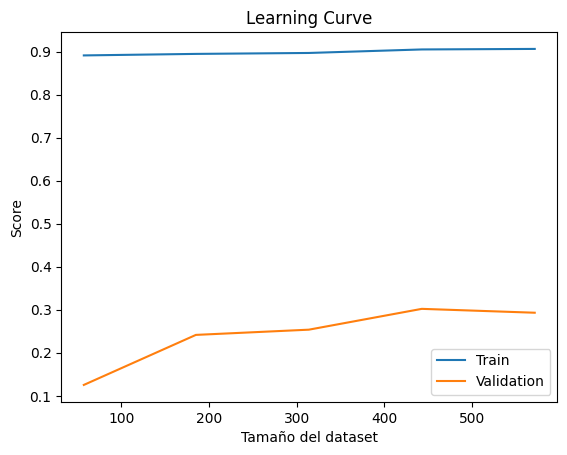

In [40]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    best_rf, X, y, cv=5
)

plt.plot(train_sizes, train_scores.mean(axis=1), label="Train")
plt.plot(train_sizes, test_scores.mean(axis=1), label="Validation")
plt.xlabel("Tamaño del dataset")
plt.ylabel("Score")
plt.title("Learning Curve")
plt.legend()
plt.show()

## Importancia de variables

Se analizan las variables más importantes del modelo para entender qué factores influyen más en la predicción.

Contrario a lo esperado, la variable más predictiva de la ansiedad resultó ser la depresión (importancia: 0.298), seguida por OCD (0.091), Age (0.064) e Insomnia (0.064). Las variables relacionadas con hábitos musicales, como Hours per day (0.031) y genre_diversity (0.027), aparecen en posiciones secundarias.

Esto refuerza el hallazgo de la Fase 1: los trastornos de salud mental están más interrelacionados entre sí que con el consumo musical directamente.

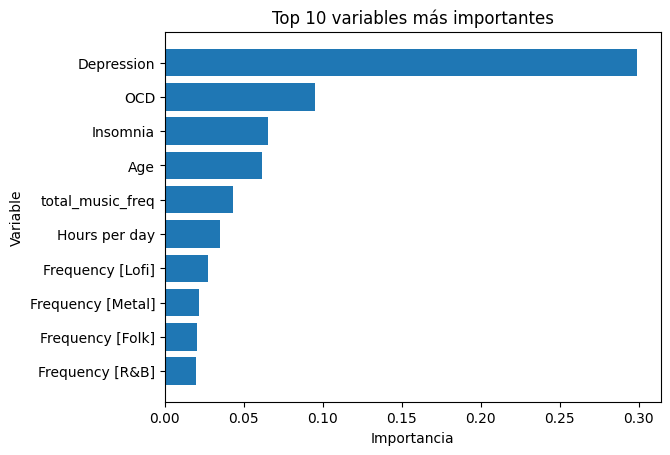

In [41]:
top_features = feature_importance.head(10)

plt.barh(top_features["Feature"], top_features["Importance"])
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.title("Top 10 variables más importantes")
plt.gca().invert_yaxis()
plt.show()

## Interpretación de resultados

Los resultados indican que Random Forest fue el modelo con mejor desempeño (RMSE: 2.25, R²: 0.35), superando tanto a la regresión lineal como a XGBoost, que resultó ser el modelo con peor desempeño de los tres.

Esto sugiere que la relación entre hábitos musicales y ansiedad no es completamente lineal, aunque tampoco es suficientemente compleja como para que XGBoost aporte una mejora significativa sobre Random Forest.

Las variables con mayor influencia en la predicción fueron otras variables de salud mental (depresión, OCD, insomnio), y no los hábitos musicales como se esperaba inicialmente. Las variables musicales tienen una influencia secundaria.

La capacidad predictiva general es limitada (R² máximo de 0.35), lo que indica que los hábitos musicales por sí solos no son suficientes para predecir la ansiedad con alta precisión.

## Conclusión

El modelo más adecuado para este problema es Random Forest, con un RMSE de 2.25 y un R² de 0.35, siendo el único que superó a la regresión lineal. XGBoost, contrario a lo esperado, obtuvo el peor desempeño de los tres modelos evaluados (RMSE: 2.42, R²: 0.25).

A pesar de ello, el modelo presenta limitaciones importantes:
- Los datos son auto-reportados, lo que introduce sesgo de respuesta
- Existe overfitting en Random Forest (Train R²: 0.90 vs Test R²: 0.35)
- El tamaño del dataset (715 registros) es limitado para modelos complejos
- No se incluyen variables externas relevantes como contexto socioeconómico o historial clínico

Para mejorar el modelo, se podría:
- Incorporar más datos para reducir el overfitting
- Aplicar técnicas de regularización o reducir la profundidad máxima del árbol
- Explorar otros modelos como Ridge Regression o SVR
- Incluir variables de contexto más relevantes

Este proyecto demuestra que los hábitos musicales tienen una relación limitada con la ansiedad. Los factores más predictivos resultaron ser otras variables de salud mental, lo que sugiere que la ansiedad debe analizarse de forma integral y no solo a partir del consumo musical.